# Self-Attention from Scratch

Self-attention is the core building block of the **Transformer** architecture. It allows every position in a sequence to look at every other position and decide *how much* to attend to it, producing a context-aware representation for each token.

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

| Symbol | Shape | Interpretation |
|--------|-------|----------------|
| $X$ | $(\text{batch},\, \text{seq\_len},\, d_{\text{model}})$ | Input token embeddings |
| $Q = XW_Q$ | $(\text{batch},\, \text{seq\_len},\, d_k)$ | **Queries** — *what am I looking for?* |
| $K = XW_K$ | $(\text{batch},\, \text{seq\_len},\, d_k)$ | **Keys** — *what information do I hold?* |
| $V = XW_V$ | $(\text{batch},\, \text{seq\_len},\, d_k)$ | **Values** — *what do I return if selected?* |

> **Scaling by $\frac{1}{\sqrt{d_k}}$** prevents dot-products from growing too large in high dimensions, which would push softmax into regions with near-zero gradients and stall training.

## 1. Imports


In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

## 2. Implementing Self-Attention

We subclass `nn.Module` and define three **learned, weight-only linear projections** — $W_Q$, $W_K$, $W_V$ — that map the input from `d_model` dimensions down to `d_k`.

**Forward pass steps:**
1. Project input $X$ → $Q$, $K$, $V$  
2. Compute raw scores: $S = QK^\top / \sqrt{d_k}$  
3. *(Optional)* Apply a mask by filling masked positions with $-\infty$ before softmax  
4. Normalize: $A = \text{softmax}(S)$  
5. Aggregate: $\text{out} = AV$

The optional `mask` parameter switches between the two modes covered in sections 3 and 4:

| `mask` | Mode | Used in |
|--------|------|---------|
| `None` | **Bidirectional** — every token sees every other token | Encoders (BERT, RoBERTa) |
| upper-triangular `True` | **Causal** — token $i$ sees only positions $j \leq i$ | Decoders (GPT series) |


In [2]:
class SelfAttention(nn.Module):
    """
    Scaled dot-product self-attention.

    Given an input sequence X of shape (batch, seq_len, d_model), projects it
    into queries, keys, and values, computes attention weights, and returns the
    weighted sum of values.

    Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V
    """

    def __init__(self, d_model: int, d_k: int | None = None):
        """
        Args:
            d_model: Dimensionality of the input embeddings.
            d_k:     Dimensionality of queries/keys/values.
                     Defaults to d_model.
        """
        super().__init__()
        self.d_k = d_k if d_k is not None else d_model

        self.W_q = nn.Linear(d_model, self.d_k, bias=False)
        self.W_k = nn.Linear(d_model, self.d_k, bias=False)
        self.W_v = nn.Linear(d_model, self.d_k, bias=False)

    def forward(
        self,
        x: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            x:    Input tensor of shape (batch, seq_len, d_model).
            mask: Optional boolean mask of shape (batch, seq_len, seq_len) or (seq_len, seq_len).
                  Positions where mask is True are masked out (set to -inf
                  before softmax), e.g. for causal / padding masks.

        Returns:
            out:     Context vectors, shape (batch, seq_len, d_k).
            weights: Attention weights,  shape (batch, seq_len, seq_len).
        """
        Q = self.W_q(x)  # (batch, seq_len, d_k)
        K = self.W_k(x)  # (batch, seq_len, d_k)
        V = self.W_v(x)  # (batch, seq_len, d_k)

        # Scaled dot-product scores: (batch, seq_len, seq_len)
        scale = math.sqrt(self.d_k)
        scores = torch.bmm(Q, K.transpose(1, 2)) / scale

        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))

        weights = F.softmax(scores, dim=-1)  # (batch, seq_len, seq_len)
        out = torch.bmm(weights, V)          # (batch, seq_len, d_k)
        return out, weights

## 3. Bidirectional Attention

Pass `mask=None` — every token attends to every other token freely, in both directions.

$$A_{ij} = \text{softmax}_j\!\left(\frac{Q_i K_j^\top}{\sqrt{d_k}}\right), \quad \forall\, i, j \in [0,\, \text{seq\_len})$$

Shape check with `d_model=16`, `d_k=8`, `seq_len=7`:

| Tensor | Shape |
|--------|-------|
| Input `x` | `(batch, seq_len, d_model)` = `(2, 7, 16)` |
| Output `out` | `(batch, seq_len, d_k)` = `(2, 7, 8)` — one context vector per token |
| Weights | `(batch, seq_len, seq_len)` = `(2, 7, 7)` — all cells positive, each row sums to 1 |



In [3]:
torch.manual_seed(0)

batch, seq_len, d_model = 2, 7, 16
x = torch.randn(batch, seq_len, d_model)

attn = SelfAttention(d_model=d_model, d_k=8)
out, weights = attn(x)  # mask=None → bidirectional

print(f"Input  shape : {x.shape}")        # (2, 7, 16)
print(f"Output shape : {out.shape}")      # (2, 7, 8)
print(f"Weights shape: {weights.shape}")  # (2, 7, 7)

# All weights > 0 (no masking) and each row must sum to 1
assert (weights > 0).all(), "Bidirectional: all weights must be positive"
assert torch.allclose(weights.sum(dim=-1), torch.ones(batch, seq_len))
print("\nAll weights positive, rows sum to 1 — bidirectional confirmed.")
print(f"\nWeights (first batch item):")
print(weights[0].detach().round(decimals=3))

Input  shape : torch.Size([2, 7, 16])
Output shape : torch.Size([2, 7, 8])
Weights shape: torch.Size([2, 7, 7])

All weights positive, rows sum to 1 — bidirectional confirmed.

Weights (first batch item):
tensor([[0.1500, 0.1440, 0.1600, 0.1220, 0.0730, 0.2250, 0.1250],
        [0.1150, 0.1220, 0.1870, 0.1280, 0.1210, 0.2000, 0.1270],
        [0.0740, 0.1780, 0.1460, 0.1100, 0.1710, 0.1840, 0.1380],
        [0.1820, 0.0550, 0.1630, 0.1630, 0.1200, 0.1220, 0.1950],
        [0.1160, 0.0970, 0.1500, 0.1080, 0.2510, 0.1730, 0.1050],
        [0.1040, 0.1850, 0.1400, 0.1360, 0.1430, 0.1230, 0.1680],
        [0.2740, 0.0640, 0.0900, 0.2380, 0.1160, 0.0830, 0.1360]])


## 4. Causal (Autoregressive) Attention

Pass an upper-triangular boolean `mask` — each token is blocked from attending to any future position. Scores at masked positions are set to $-\infty$ before softmax, driving those weights to exactly zero.

$$A_{ij} = \begin{cases} \text{softmax}_j\!\left(\dfrac{Q_i K_j^\top}{\sqrt{d_k}}\right) & j \leq i \\ 0 & j > i \end{cases}$$

```python
causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)
# True  where j > i  →  blocked  (future positions)
# False where j ≤ i  →  allowed  (current + past)
```

- `diagonal=1` keeps the main diagonal `False` — a token can still attend to itself.
- Softmax over a row with $-\infty$ future positions redistributes all probability mass over the $i+1$ allowed positions.
- This enforces **no future token leakage**: when predicting token $i$, positions $i{+}1, \ldots, \text{seq\_len}$ are invisible.


In [4]:
torch.manual_seed(0)

batch, seq_len, d_model = 2, 7, 16
x = torch.randn(batch, seq_len, d_model)

attn = SelfAttention(d_model=d_model, d_k=8)

# Upper-triangle mask: True at (i, j) where j > i (future positions → blocked)
causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)
out_causal, weights_causal = attn(x, mask=causal_mask)

# Future positions must carry exactly zero weight (softmax(-inf) = 0)
assert (weights_causal[:, causal_mask] < 1e-9).all(), "Future positions must have zero weight"
print("Causal mask check passed — no future token leakage.")
print(f"\nCausal weights (first batch item):")
print(weights_causal[0].detach().round(decimals=3))
print("\nNotice: upper triangle is 0.000 — token i cannot attend to positions j > i.")

Causal mask check passed — no future token leakage.

Causal weights (first batch item):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4840, 0.5160, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1870, 0.4470, 0.3670, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3230, 0.0980, 0.2890, 0.2900, 0.0000, 0.0000, 0.0000],
        [0.1600, 0.1340, 0.2070, 0.1500, 0.3480, 0.0000, 0.0000],
        [0.1260, 0.2230, 0.1690, 0.1640, 0.1720, 0.1480, 0.0000],
        [0.2740, 0.0640, 0.0900, 0.2380, 0.1160, 0.0830, 0.1360]])

Notice: upper triangle is 0.000 — token i cannot attend to positions j > i.


## 5. Visualization

We plot the $7 \times 7$ attention weight matrix as a heatmap for both modes, using the sentence *"The CEO announced record earnings on Friday"*.

| # | Configuration | Mask applied | Expected pattern |
|---|--------------|--------------|-----------------|
| 1 | **Bidirectional** | None | All cells active — every token can attend to every other token |
| 2 | **Causal** | Upper-triangle set to $-\infty$ | Strict lower-triangular — token $i$ can only attend to positions $j \leq i$ |



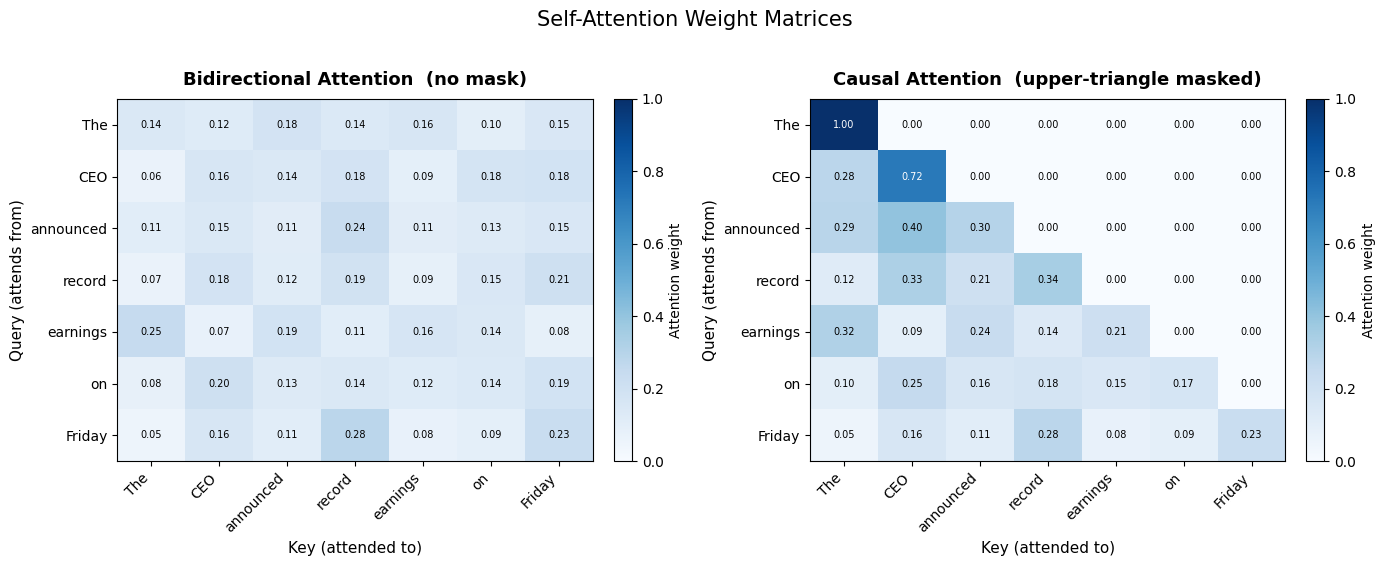

In [5]:
import matplotlib.pyplot as plt

# ── shared setup ────────────────────────────────────────────────────────────
torch.manual_seed(42)

tokens  = ["The", "CEO", "announced", "record", "earnings", "on", "Friday"]
seq_len = len(tokens)
d_model = 16

x = torch.randn(1, seq_len, d_model)     # batch of 1
attn = SelfAttention(d_model=d_model, d_k=8)

# ── 1. Full attention (no mask) ──────────────────────────────────────────────
_, w_full = attn(x)                       # (1, seq_len, seq_len)
w_full = w_full[0].detach().numpy()

# ── 2. Causal attention ──────────────────────────────────────────────────────
causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)
_, w_causal = attn(x, mask=causal_mask)
w_causal = w_causal[0].detach().numpy()

# ── plotting ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

def plot_attn(ax, weights, title):
    im = ax.imshow(weights, vmin=0, vmax=1, cmap="Blues", aspect="auto")
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(tokens, fontsize=10)
    ax.set_xlabel("Key (attended to)", fontsize=11)
    ax.set_ylabel("Query (attends from)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, f"{weights[i, j]:.2f}",
                    ha="center", va="center", fontsize=7,
                    color="white" if weights[i, j] > 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Attention weight")

plot_attn(axes[0], w_full,   "Bidirectional Attention  (no mask)")
plot_attn(axes[1], w_causal, "Causal Attention  (upper-triangle masked)")

plt.suptitle("Self-Attention Weight Matrices", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
